In [9]:
import pandas as pd
df = pd.read_csv('./data/outputs/llm_bias_labels.csv')
print(f'Parse failure rate: {df["parse_failed"].mean()*100:.1f}%')
print(f'Avg retries: {df["n_retries"].mean():.2f}')
print(df[['text','label_name','llm_label','llm_rationale']].head(10).to_string())

Parse failure rate: 0.0%
Avg retries: 0.00
                                                                                                                                                                                                                                           text  label_name   llm_label                                                                   llm_rationale
0                                               An ongoing shift of the population toward non-white demographics means that, assuming no change in voting behavior of these various groups, electing Republicans will become harder and harder.  non-biased      biased  Loaded evaluative language: 'harder and harder' implies difficulty is inherent
1                                                                    Winners of moraingy bouts received a cash prize and it offered a way for insecure young people to feel good about themselves using the only things they had: their bodies.      biased      biased      

Parse failures excluded from metrics: 0 / 300

Ground-truth label distribution:
label_name
non-biased    150
biased        150
Name: count, dtype: int64

LLM predicted label distribution:
llm_label
biased        230
non-biased     70
Name: count, dtype: int64

Accuracy: 0.6733
Macro-F1: 0.6483

              precision    recall  f1-score   support

      biased       0.61      0.94      0.74       150
  non-biased       0.87      0.41      0.55       150

    accuracy                           0.67       300
   macro avg       0.74      0.67      0.65       300
weighted avg       0.74      0.67      0.65       300



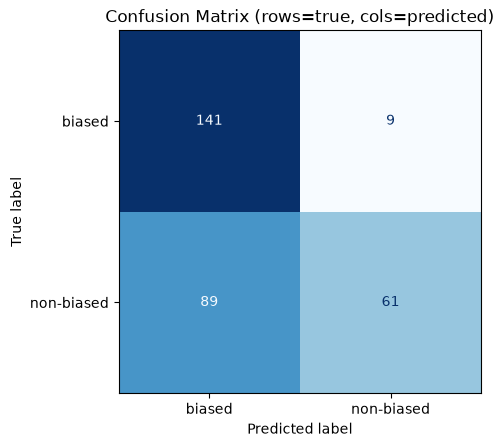

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay
df = pd.read_csv("./data/outputs/llm_bias_labels.csv")
# Handle parse failures separately -- don't let them silently corrupt the metrics
failed = df[df["llm_label"].isna()]
valid = df[df["llm_label"].notna()].copy()
print(f"Parse failures excluded from metrics: {len(failed)} / {len(df)}")
print(f"\nGround-truth label distribution:\n{valid['label_name'].value_counts()}")
print(f"\nLLM predicted label distribution:\n{valid['llm_label'].value_counts()}")
y_true = valid["label_name"]
y_pred = valid["llm_label"]
print(f"\nAccuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro-F1: {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"\n{classification_report(y_true, y_pred)}")

# Confusion matrix as a plot instead of a printed array
cm = confusion_matrix(y_true, y_pred, labels=["biased", "non-biased"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["biased", "non-biased"])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion Matrix (rows=true, cols=predicted)")
plt.tight_layout()
plt.show()